In [2]:
import pandas as pd
import numpy as np


In [23]:
df = pd.read_csv("../data/processed/operations_cleaned.csv")

In [24]:
site_id = "SITE_001"
site_df = df[df['site_id']==site_id].copy()

In [25]:
# this is to sort the table based on date
site_df.set_index('date',inplace=True)
site_df= site_df.sort_index()

In [26]:
df

,date,site_id,region,behavior,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity,capacity_violation,opening_overflow_tonnes,closing_overflow_tonnes
0,2022-01-01,SITE_001,North,aggressive,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448,False,0.0,0.0
1,2022-01-02,SITE_001,North,aggressive,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448,False,0.0,0.0
2,2022-01-03,SITE_001,North,aggressive,CEM_III,38.69,38.69,38.56,47.19,47.06,2.64,6.40,448,False,0.0,0.0
3,2022-01-04,SITE_001,North,aggressive,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448,False,0.0,0.0
4,2022-01-05,SITE_001,North,aggressive,CEM_III,56.88,47.04,32.64,14.40,0.00,2.69,8.97,448,False,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32875,2024-12-27,SITE_030,South,aggressive,CEM_III,58.48,29.63,0.00,29.63,0.00,7.17,12.00,316,False,0.0,0.0
32876,2024-12-28,SITE_030,South,aggressive,CEM_I,45.39,22.35,0.00,22.35,0.00,2.13,8.04,316,False,0.0,0.0
32877,2024-12-29,SITE_030,South,aggressive,CEM_III,58.47,14.21,0.00,14.21,0.00,0.28,2.26,316,False,0.0,0.0
32878,2024-12-30,SITE_030,South,aggressive,CEM_II,59.58,10.65,0.00,10.65,0.00,4.58,9.55,316,False,0.0,0.0


In [27]:
y=site_df['consumed_tonnes']
exog = site_df[['planned_pour_tonnes', 'opening_inventory_tonnes', 'deliveries_tonnes'	, 'closing_inventory_tonnes'		, 'rain_mm'	, 'avg_temp_c'	, 'silo_capacity'	]]

# Checkking for seasonality

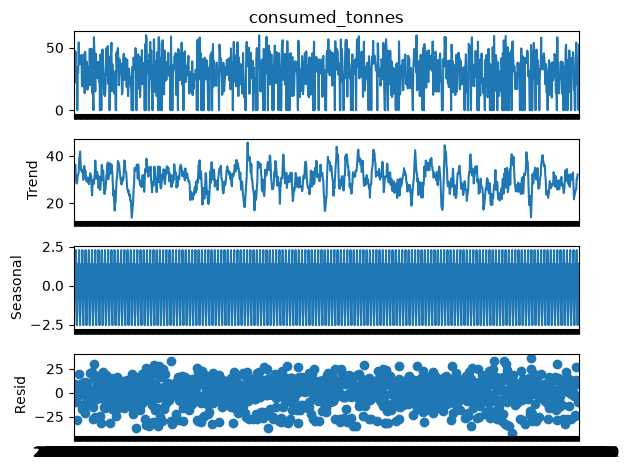

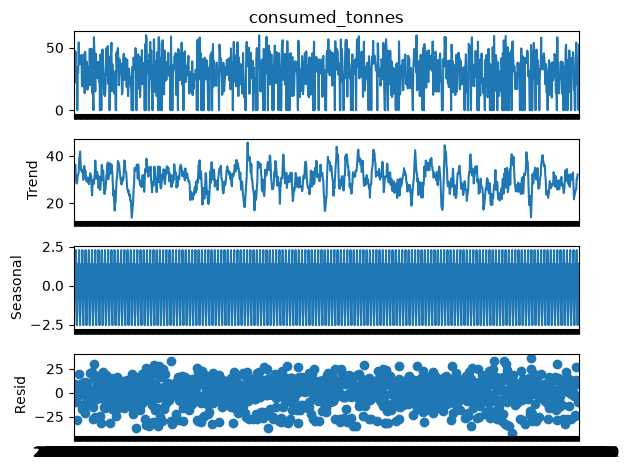

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(y, model = 'additive', period=7)
decomp.plot()

Training SARIMAX Model


In [29]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


# Splitting DATA
split_index = int(len(site_df)*0.8)

x_train, x_test = exog.iloc[:split_index], exog.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [30]:
x_train

,planned_pour_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
date,,,,,,,
2022-01-01,43.18,52.56,45.83,63.85,3.40,-3.10,448
2022-01-02,45.26,63.85,19.97,38.56,3.23,14.28,448
2022-01-03,38.69,38.56,47.19,47.06,2.64,6.40,448
2022-01-04,33.16,47.06,18.74,32.64,8.25,14.23,448
2022-01-05,56.88,32.64,14.40,0.00,2.69,8.97,448
...,...,...,...,...,...,...,...
2024-05-21,47.56,0.00,47.36,0.00,6.04,20.54,448
2024-05-22,59.37,0.00,30.08,0.00,0.70,16.61,448
2024-05-23,47.46,0.00,44.57,0.00,12.04,23.49,448


In [31]:
order=(1,1,1)
seasonal_order=(1,0,1,7)

In [32]:
model = SARIMAX(
    y_train,
    exog=x_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False

)

results =model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                   consumed_tonnes   No. Observations:                  876
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood                9174.354
Date:                           Mon, 10 Aug 2026   AIC                         -18324.707
Time:                                   13:32:50   BIC                         -18267.541
Sample:                               01-01-2022   HQIC                        -18302.829
                                    - 05-25-2024                                         
Covariance Type:                             opg                                         
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
planned_pour_tonnes      -1.952e-17   5.24e-23  -3.73e+05      0.000   -1.95e-17   -1.95e-17
opening_inventory_tonnes     1.0000   2.91e-22   3.44e+21      0.000       1.000       1.000
deliveries_tonnes            1.0000   2.21e-22   4.53e+21      0.000       1.000       1.000
closing_inventory_tonnes    -1.0000   5.05e-23  -1.98e+22      0.000      -1.000      -1.000
rain_mm                   1.457e-16   4.31e-24   3.38e+07      0.000    1.46e-16    1.46e-16
avg_temp_c                2.082e-17    4.7e-24   4.42e+06      0.000    2.08e-17    2.08e-17
silo_capacity                     0         -0        nan        nan           0           0
ar.L1                        0.0547   1.66e-24   3.29e+22      0.000       0.055       0.055
ma.L1                       -0.4508   3.01e-23   -1.5e+22      0.000      -0.451      -0.451
ar.S.L7                      0.0377   9.44e-24   3.99e+21      0.000       0.038       0.038
ma.S.L7                     -0.0735    6.9e-23  -1.06e+21      0.000      -0.073      -0.073
sigma2                        1e-10   6.73e-11      1.485      0.138    -3.2e-11    2.32e-10
===================================================================================
Ljung-Box (L1) (Q):                   0.49   Jarque-Bera (JB):                81.10
Prob(Q):                              0.48   Prob(JB):                         0.00
Heteroskedasticity (H):               1.01   Skew:                            -0.40
Prob(H) (two-sided):                  0.93   Kurtosis:                         4.26
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.17e+57. Standard errors may be unstable.
"""

In [33]:
y_pred = results.predict(start=y_test.index[0], end=y_test.index[-1], exog=x_test)

In [34]:
from sklearn.metrics import mean_absolute_percentage_error , root_mean_squared_error

MAPE = mean_absolute_percentage_error(y_test,y_pred)
print(f"MAPE = {MAPE}")

RMSE = root_mean_squared_error(y_test,y_pred)
print(f"RMSE= {RMSE}")

MAPE = 17.714368401755973
RMSE= 3.5044688886742555e-14


In [33]:
metrics = {RMSE, MAPE}

In [59]:
import mlflow
import mlflow.statsmodels
from mlflow.models.signature import infer_signature
import numpy as np
#from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
# 1. Set tracking URI & Experiment
mlflow.set_tracking_uri("sqlite:///mlflow.db")  # or "sqlite:///mlflow.db"
mlflow.set_experiment("Cement Demand SARIMAX Forecasting")
# 2. Log run after training
with mlflow.start_run(run_name=f"SARIMAX_{site_id}"):
    """
    # Track Parameters
    mlflow.log_params({
        "site_id": site_id,
        "target_col": y,
        "exog_cols": str(x_train),
        "order": str(order),
        "seasonal_order": str(seasonal_order),
        "train_size": len(y_train),
        "test_size": len(y_test)
    })
    """
    # Calculate & Log Metrics (RMSE, MAE, Zero-Safe MAPE, AIC, BIC)
    
    mlflow.log_metrics({
        "RMSE": RMSE,
        "MAPE": MAPE
        
    })
    # Set Tag
    mlflow.set_tag("training_information", f"SARIMAX Model for {site_id}")
    # Log Model (using mlflow.statsmodels flavor)
    signature = infer_signature(x_train, y_train)
    mlflow.statsmodels.log_model(
        statsmodels_model=results,
        name=f"sarimax_model_{site_id}",
        signature=signature,
        
    )

c:\Users\gideo\OneDrive\Desktop\ADMARI\Admari 2\Cement demand forcasting\Cement-Demand-Forecasting\venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


c:\Users\gideo\OneDrive\Desktop\ADMARI\Admari 2\Cement demand forcasting\Cement-Demand-Forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\gideo\OneDrive\Desktop\ADMARI\Admari 2\Cement demand forcasting\Cement-Demand-Forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\gideo\OneDrive\Desktop\ADMARI\Admari 2\Cement demand forcasting\Cement-Demand-Forecasting\venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


MAPE = 9489892018.372635
RMSE= 6.309666022468426e-05


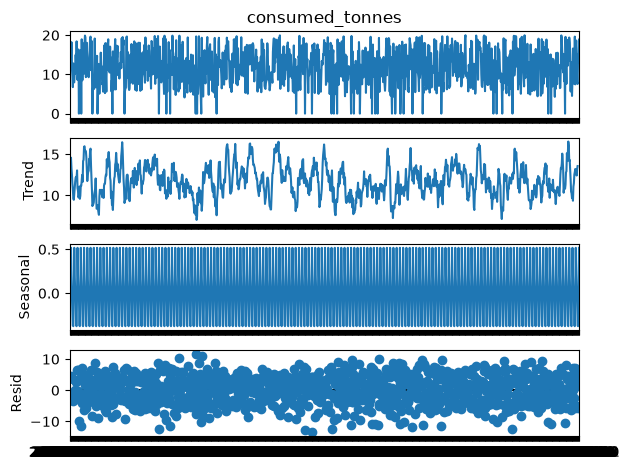

In [ ]:
# Training Cement consumption on Sarimax for SITE 2
site_id = "SITE_002"
site_df = df[df['site_id']==site_id].copy()
# this is to sort the table based on date
site_df.set_index('date',inplace=True)
site_df= site_df.sort_index()
y=site_df['consumed_tonnes']
exog = site_df[['planned_pour_tonnes', 'opening_inventory_tonnes', 'deliveries_tonnes'	, 'closing_inventory_tonnes'		, 'rain_mm'	, 'avg_temp_c'	, 'silo_capacity'	]]

# Cecking for seasonality 
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(y, model = 'additive', period=7)
decomp.plot()

from statsmodels.tsa.statespace.sarimax import SARIMAX


# Splitting DATA
split_index = int(len(site_df)*0.8)

# Training SAARIMAX
x_train, x_test = exog.iloc[:split_index], exog.iloc[split_index:]
order=(1,1,1)
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


seasonal_order=(1,0,1,7)
model = SARIMAX(
    y_train,
    exog=x_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False

)

results =model.fit()
results.summary()




# Testin 
y_pred = results.predict(start=y_test.index[0], end=y_test.index[-1], exog=x_test)

from sklearn.metrics import mean_absolute_percentage_error , root_mean_squared_error

MAPE = mean_absolute_percentage_error(y_test,y_pred)
print(f"MAPE = {MAPE}")

RMSE = root_mean_squared_error(y_test,y_pred)
print(f"RMSE= {RMSE}")

c:\Users\gideo\OneDrive\Desktop\ADMARI\Admari 2\Cement demand forcasting\Cement-Demand-Forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\gideo\OneDrive\Desktop\ADMARI\Admari 2\Cement demand forcasting\Cement-Demand-Forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\gideo\OneDrive\Desktop\ADMARI\Admari 2\Cement demand forcasting\Cement-Demand-Forecasting\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\gideo\OneDrive\Desktop\ADMARI\Admari 2\Cement demand forcasting\Cement-Demand-Forecasting\venv\Lib\site-packages\statsm

MAPE = 48.65973790585283
RMSE= 9.702400790314998e-14


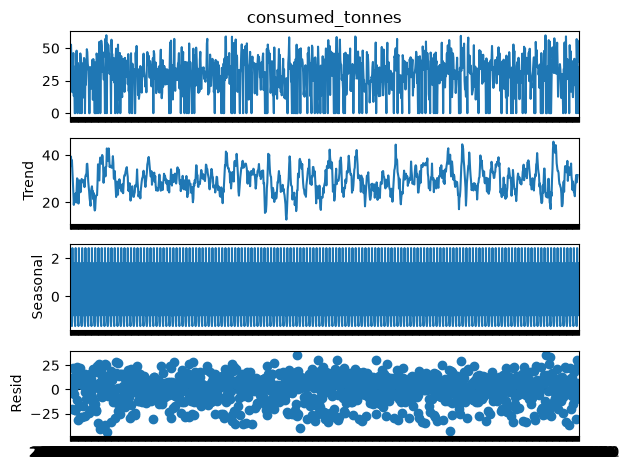

In [15]:
# Training Cement consumption on Sarimax for SITE 3
site_id = "SITE_003"
site_df = df[df['site_id']==site_id].copy()
# this is to sort the table based on date
site_df.set_index('date',inplace=True)
site_df= site_df.sort_index()
y=site_df['consumed_tonnes']
exog = site_df[['planned_pour_tonnes', 'opening_inventory_tonnes', 'deliveries_tonnes'	, 'closing_inventory_tonnes'		, 'rain_mm'	, 'avg_temp_c'	, 'silo_capacity'	]]

# Cecking for seasonality 
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(y, model = 'additive', period=7)
decomp.plot()

from statsmodels.tsa.statespace.sarimax import SARIMAX


# Splitting DATA
split_index = int(len(site_df)*0.8)

# Training SAARIMAX
x_train, x_test = exog.iloc[:split_index], exog.iloc[split_index:]
order=(1,1,1)
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


seasonal_order=(1,0,1,7)
model = SARIMAX(
    y_train,
    exog=x_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False

)

results =model.fit()
results.summary()




# Testin 
y_pred = results.predict(start=y_test.index[0], end=y_test.index[-1], exog=x_test)

from sklearn.metrics import mean_absolute_percentage_error , root_mean_squared_error

MAPE = mean_absolute_percentage_error(y_test,y_pred)
print(f"MAPE = {MAPE}")

RMSE = root_mean_squared_error(y_test,y_pred)
print(f"RMSE= {RMSE}")

c:\Users\gideo\OneDrive\Desktop\ADMARI\Admari 2\Cement demand forcasting\Cement-Demand-Forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\gideo\OneDrive\Desktop\ADMARI\Admari 2\Cement demand forcasting\Cement-Demand-Forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\gideo\OneDrive\Desktop\ADMARI\Admari 2\Cement demand forcasting\Cement-Demand-Forecasting\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\gideo\OneDrive\Desktop\ADMARI\Admari 2\Cement demand forcasting\Cement-Demand-Forecasting\venv\Lib\site-packages\statsm

MAPE = 632.8117009605213
RMSE= 2.3696409189956863e-12


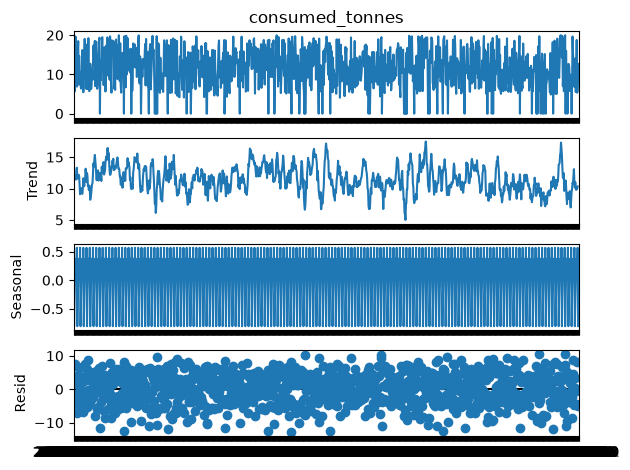

In [16]:
# Training Cement consumption on Sarimax for SITE 4
site_id = "SITE_004"
site_df = df[df['site_id']==site_id].copy()
# this is to sort the table based on date
site_df.set_index('date',inplace=True)
site_df= site_df.sort_index()
y=site_df['consumed_tonnes']
exog = site_df[['planned_pour_tonnes', 'opening_inventory_tonnes', 'deliveries_tonnes'	, 'closing_inventory_tonnes'		, 'rain_mm'	, 'avg_temp_c'	, 'silo_capacity'	]]

# Cecking for seasonality 
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(y, model = 'additive', period=7)
decomp.plot()

from statsmodels.tsa.statespace.sarimax import SARIMAX


# Splitting DATA
split_index = int(len(site_df)*0.8)

# Training SAARIMAX
x_train, x_test = exog.iloc[:split_index], exog.iloc[split_index:]
order=(1,1,1)
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


seasonal_order=(1,0,1,7)
model = SARIMAX(
    y_train,
    exog=x_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False

)

results =model.fit()
results.summary()




# Testin 
y_pred = results.predict(start=y_test.index[0], end=y_test.index[-1], exog=x_test)

from sklearn.metrics import mean_absolute_percentage_error , root_mean_squared_error

MAPE = mean_absolute_percentage_error(y_test,y_pred)
print(f"MAPE = {MAPE}")

RMSE = root_mean_squared_error(y_test,y_pred)
print(f"RMSE= {RMSE}")

In [47]:
f = pd.read_csv("../data/processed/operations_cleaned.csv")
import warnings
warnings.filterwarnings('ignore')
site_ID = df['site_id'].unique()
for i in site_ID:
    print(i)
    

SITE_001
SITE_002
SITE_003
SITE_004
SITE_005
SITE_006
SITE_007
SITE_008
SITE_009
SITE_010
SITE_011
SITE_012
SITE_013
SITE_014
SITE_015
SITE_016
SITE_017
SITE_018
SITE_019
SITE_020
SITE_021
SITE_022
SITE_023
SITE_024
SITE_025
SITE_026
SITE_027
SITE_028
SITE_029
SITE_030


In [ ]:
import pandas as pd
df = pd.read_csv("../data/processed/operations_cleaned.csv")
import warnings
warnings.filterwarnings('ignore')
site_ID = df['site_id'].unique()
def site_by_site_training(id):
    # Training Cement consumption on Sarimax for SITE 2
    site_id = id
    site_df = df[df['site_id']==site_id].copy()

    # this is to sort the table based on date
    site_df.set_index('date',inplace=True)
    site_df= site_df.sort_index()

    y=site_df['consumed_tonnes']
    exog = site_df[['planned_pour_tonnes', 'opening_inventory_tonnes', 'deliveries_tonnes'	, 'closing_inventory_tonnes'		, 'rain_mm'	, 'avg_temp_c'	, 'silo_capacity'	]]

    # Cecking for seasonality 
    from statsmodels.tsa.seasonal import seasonal_decompose
    decomp = seasonal_decompose(y, model = 'additive', period=7)
    #decomp.plot()

    from statsmodels.tsa.statespace.sarimax import SARIMAX


    # Splitting DATA
    split_index = int(len(site_df)*0.8)

    # Training SAARIMAX
    x_train, x_test = exog.iloc[:split_index], exog.iloc[split_index:]
    
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

    order=(1,1,1)
    seasonal_order=(1,0,1,7)
    model = SARIMAX(
        y_train,
        exog=x_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False

    )

    results =model.fit()
    results.summary()




    # Testin 
    # Get forecast using the model's training index
    y_pred = results.forecast(steps=len(y_test), exog=x_test)
    #y_pred = results.predict(start=y_test.index[0], end=y_test.index[-1], exog=x_test)
    
   

    from sklearn.metrics import mean_absolute_percentage_error , root_mean_squared_error

    MAPE = mean_absolute_percentage_error(y_test,y_pred)
    print(f"MAPE = {MAPE}")

    RMSE = root_mean_squared_error(y_test,y_pred)
    

    print(f"RMSE= {RMSE}")
    return MAPE, RMSE



for i in site_ID:
    print(i)
    site_by_site_training(i)
    #print(f" MAPE:{MAPE}, RMSE:{RMSE}")

"""

for i in df['site_id'].unique():
    print(f"Processing: {site_id}")
    site_by_site_training(site_id)
    print(f" MAPE:{MAPE}, RMSE:{RMSE}")




"""

SITE_001
MAPE = 17.714368401755973
for y_test= [54.68 28.18  0.   40.29 32.99 11.57 28.28 30.32 45.29 23.55 21.16 25.69
 13.48 20.35 16.46 40.23 19.09 44.07 27.27 38.22 10.36 25.91 48.98 14.98
 37.43 31.48 30.2  35.85 50.31 18.37 59.29 26.75 22.51 15.48 40.07 30.06
 35.45 38.26 14.56 11.38 21.86 31.13 15.16 15.43 41.6  34.65 45.43 55.75
 35.39 31.58 59.18 40.05 20.17 50.51 28.42 46.24 27.03 32.32 42.76 44.92
 47.39 49.38 54.98 45.5  36.69 31.29 34.99 24.64 16.89 30.14 22.8  16.79
 38.04 30.96 27.16 27.58 32.52 37.82 22.67 49.39 24.45 43.11 34.63 37.09
 28.62 41.91 41.49 37.75 40.83 37.58 47.59 43.9  27.11 31.52 31.49 51.98
 46.2  32.85 40.14 53.74 47.02 24.41 39.7  48.39 30.94 34.92 39.81 20.59
 29.66 26.54 32.68 35.77 58.04 33.2  35.12 32.56 35.53 42.57 45.36 41.34
 31.18 20.79 36.88 33.45 13.95 28.85 31.3  29.3  39.99 12.18 23.27 36.3
 26.2  37.68 10.05 38.33 23.46 24.42 31.27 26.91 45.03 42.58 28.89 13.57
 31.12 58.23 25.39 38.54 13.41 17.97 29.78 24.78 30.66 38.85 37.3  13.38
 38.5

KeyboardInterrupt: 

In [ ]:
# ----------------------------------------------------
    # SET TAGS
    # ----------------------------------------------------
mlflow.set_tag("training_information", f"SARIMAX Time Series Model for {site_id}")
mlflow.set_tag("model_type", "SARIMAX")

In [16]:
import mlflow

# After the server is runningn, set the tracking URI to point to the server. This is where MLflow will log all the experiments and runs.
mlflow.set_tracking_uri("http://127.0.0.1:5000") # this could be a remote url

mlflow.set_experiment("Customer churn")

with mlflow.start_run():
    # track parameters

    # log metrics
    mlflow.log_metrics({"RMSE":RMSE, "MAPE":MAPE})

    # Setting a tag for this traing run 
    mlflow.set_tag("training information", "Radomforest model")

    # log model
    signature= infer_signature(X_train,rf_model.predict(X_train))
    model_info= mlflow.sklearn.log_model(
        sk_model=rf_model,
        name="Customer Churn RF",
        signature=signature,
        input_example=X_train
    )


